# Swin + DINO Self-Supervised Pretraining: WaRP-C Hard Class Recovery
**Author:** El Mehdi Ziate


## Setup

In [ ]:
import sys, copy, json, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from PIL import Image
from sklearn.metrics import confusion_matrix
import seaborn as sns

root = Path.cwd()
while not (root / 'Pipeline_').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from Models.swin import SwinTransformerWaRP
from Pipeline_.preprocessor import WaRPPreprocessor, PadToSquare

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_CLASSES = 28
BEST_PATH   = root / 'Models/weights/swin_optimised_best.pth'

# Hard classes from confusion matrix: these get extra weight
HARD_CLASSES = [
    'bottle-oil-full',        # 50%
    'bottle-multicolor',      # 46%
    'bottle-multicolorv-full',# 62%
    'bottle-blue5l-full',     # 58%
    'detergent-transparent',  # 66%
]
print(f'Device: {DEVICE}')


Device: cuda


## DINO Augmentation


In [ ]:
class DINOAugmentation:
    """
    DINO multi-crop augmentation (Caron et al. ICCV 2021).

    Produces:
      - 2 global views (224x224, large crop scale 0.4-1.0)
      - n_local small views (96x96, small crop scale 0.05-0.4)
    """
    def __init__(self, n_local: int = 4):
        self.n_local = n_local

        # Global view: large crop, strong augmentation
        self.global_transform = T.Compose([
            PadToSquare('reflect'),
            T.RandomResizedCrop(224, scale=(0.4, 1.0), interpolation=3),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.4, contrast=0.4,
                          saturation=0.2, hue=0.05),
            T.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0)),
            T.ToTensor(),
            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])

        # Local view: small crop, light augmentation
        self.local_transform = T.Compose([
            PadToSquare('reflect'),
            T.RandomResizedCrop(224, scale=(0.05, 0.4), interpolation=3),  # upsampled to 224 for Swin
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.4, contrast=0.4,
                          saturation=0.2, hue=0.05),
            T.ToTensor(),
            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])

    def __call__(self, img):
        views = []
        # 2 global views for teacher + student
        views.append(self.global_transform(img))
        views.append(self.global_transform(img))
        # n_local local views for student only
        for _ in range(self.n_local):
            views.append(self.local_transform(img))
        return views


class WaRPUnlabeledDataset(Dataset):
    """
    Dataset for self-supervised pretraining: ignores labels entirely.
    Uses ALL WaRP-C training images as unlabeled data.
    """
    def __init__(self, root, transform):
        self.dataset   = ImageFolder(root, transform=None)
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]    # label ignored
        views  = self.transform(img)
        return views                  # list of tensors, no label


def dino_collate(batch):
    """Stack each view position across the batch."""
    n_views = len(batch[0])
    return [torch.stack([b[i] for b in batch]) for i in range(n_views)]


dino_aug = DINOAugmentation(n_local=4)
ssl_dataset = WaRPUnlabeledDataset(
    root      = root / 'Dataset/processed/train',
    transform = dino_aug,
)
ssl_loader = DataLoader(
    ssl_dataset, batch_size=32, shuffle=True,
    num_workers=0, collate_fn=dino_collate,
    pin_memory=(DEVICE=='cuda'),
)
print(f'SSL dataset: {len(ssl_dataset)} images')
print(f'Views per image: 2 global + 4 local = 6')


SSL dataset: 8767 images
Views per image: 2 global + 4 local = 6


## DINO Model

In [ ]:
class DINOHead(nn.Module):
    """
    DINO projection head: maps backbone features to K-dim output.
    """
    def __init__(self, in_dim: int = 768, out_dim: int = 4096,
                 hidden_dim: int = 512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
        )
        self.last = nn.utils.weight_norm(
            nn.Linear(hidden_dim // 2, out_dim, bias=False)
        )
        self.last.weight_g.data.fill_(1)
        self.last.weight_g.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.net(x)
        x = F.normalize(x, dim=-1, p=2)
        return self.last(x)


class DINOSwin(nn.Module):
    """
    Swin backbone + DINO head. Used for both student and teacher.
    """
    def __init__(self, out_dim: int = 4096):
        super().__init__()
        # Load pretrained Swin backbone 
        base = SwinTransformerWaRP(
            num_classes=NUM_CLASSES, pretrained=True
        )
        self.backbone = base.backbone   # 768-dim features
        self.head     = DINOHead(in_dim=768, out_dim=out_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.backbone(x)         # (B, 768)
        return self.head(feat)          # (B, out_dim)


# Build student and teacher
student = DINOSwin(out_dim=1024).to(DEVICE)
teacher = DINOSwin(out_dim=1024).to(DEVICE)

# Teacher starts as exact copy of student
teacher.load_state_dict(student.state_dict())
for p in teacher.parameters():
    p.requires_grad = False

total_s = sum(p.numel() for p in student.parameters() if p.requires_grad)
print(f'Student params : {total_s:,}')
print(f'Teacher params : frozen (EMA of student)')


[SwinTransformerWaRP] Loaded pretrained swin_tiny_patch4_window7_224
  Backbone features : 768
  Head              : Linear(768 → 28)
  Parameters        : 27,540,886


c:\Users\El Mehdi Ziate\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


[SwinTransformerWaRP] Loaded pretrained swin_tiny_patch4_window7_224
  Backbone features : 768
  Head              : Linear(768 → 28)
  Parameters        : 27,540,886
Student params : 28,307,578
Teacher params : frozen (EMA of student)


## DINO Loss

the DINO loss is:

```
L = -p2 * log(p1)
```


In [ ]:
class DINOLoss(nn.Module):
    """
    DINO self-distillation loss
    """
    def __init__(self, out_dim: int = 4096,
                 student_temp: float = 0.1,
                 teacher_temp: float = 0.04,
                 center_momentum: float = 0.9):
        super().__init__()
        self.student_temp    = student_temp
        self.teacher_temp    = teacher_temp
        self.center_momentum = center_momentum
        self.register_buffer('center', torch.zeros(1, out_dim))

    def forward(self, student_out: list[torch.Tensor],
                teacher_out: list[torch.Tensor]) -> torch.Tensor:
        """
        student_out: list of (B, out_dim) tensors for all views
        teacher_out: list of (B, out_dim) tensors for global views only
        """
        # Sharpen teacher with centering
        teacher_soft = [
            F.softmax((t - self.center) / self.teacher_temp, dim=-1)
            for t in teacher_out
        ]

        total_loss = 0.0
        n_pairs    = 0

        for i, s in enumerate(student_out):
            s_log = F.log_softmax(s / self.student_temp, dim=-1)
            for j, t in enumerate(teacher_soft):
                if i == j:
                    continue  # skip same-view pairs
                total_loss += -(t * s_log).sum(dim=-1).mean()
                n_pairs    += 1

        loss = total_loss / n_pairs

        # Update center with EMA (prevents collapse)
        with torch.no_grad():
            batch_center = torch.cat(teacher_out).mean(dim=0, keepdim=True)
            self.center  = (self.center * self.center_momentum
                            + batch_center * (1 - self.center_momentum))

        return loss


dino_loss = DINOLoss(out_dim=1024).to(DEVICE)
print('[DINOLoss] ready')


[DINOLoss] ready


## DINO Pretraining Loop

In [ ]:
# Run this FIRST to clear any leftover GPU memory
import gc
torch.cuda.empty_cache()
gc.collect()

# Then rebuild with smaller settings
dino_aug = DINOAugmentation(n_local=2)  # was 4: now 2+2=4 total views
ssl_dataset = WaRPUnlabeledDataset(
    root      = root / 'Dataset/processed/train',
    transform = dino_aug,
)
ssl_loader = DataLoader(
    ssl_dataset, batch_size=16,   # was 32: halved
    shuffle=True, num_workers=0,
    collate_fn=dino_collate,
)
print(f'Views: 2 global + 2 local = 4 total')
print(f'Batch: 16')

Views: 2 global + 2 local = 4 total
Batch: 16


In [ ]:
def update_teacher_ema(student, teacher, momentum: float):
    """
    EMA update: teacher = momentum * teacher + (1-momentum) * student.
    """
    with torch.no_grad():
        for s_p, t_p in zip(student.parameters(), teacher.parameters()):
            t_p.data = t_p.data * momentum + s_p.data * (1 - momentum)


def train_dino(
    student, teacher, dino_loss, loader,
    epochs=30, base_lr=5e-4,
    ema_momentum_start=0.996, ema_momentum_end=1.0,
    save_path=None,
):
    """
    DINO self-supervised pretraining.

    EMA momentum increases from 0.996 to 1.0 over training
    (teacher becomes more stable as training progresses).

    Uses cosine learning rate schedule with warmup.
    """
    optimizer = torch.optim.AdamW(
        student.parameters(), lr=base_lr, weight_decay=0.04
    )
    scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda'))
    history   = []

    total_steps = epochs * len(loader)
    warmup_steps = 10 * len(loader)

    step = 0
    for epoch in range(1, epochs + 1):
        student.train()
        epoch_loss = 0.0

        for views in loader:
            views = [v.to(DEVICE) for v in views]

            # Cosine LR with warmup
            if step < warmup_steps:
                lr = base_lr * step / warmup_steps
            else:
                progress = (step - warmup_steps) / (total_steps - warmup_steps)
                lr = base_lr * 0.5 * (1 + np.cos(np.pi * progress))
            for pg in optimizer.param_groups:
                pg['lr'] = lr

            # EMA momentum schedule
            m = ema_momentum_end - (ema_momentum_end - ema_momentum_start) \
                * (np.cos(np.pi * step / total_steps) + 1) / 2

            # Forward: student sees all views, teacher sees only global (0, 1)
            with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):
                s_out = [student(v) for v in views]
                with torch.no_grad():
                    t_out = [teacher(views[0]), teacher(views[1])]
                loss  = dino_loss(s_out, t_out)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            # Clip gradients — DINO training is sensitive to large gradients
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(student.parameters(), 3.0)
            scaler.step(optimizer)
            scaler.update()

            # Update teacher with EMA
            update_teacher_ema(student, teacher, momentum=m)

            epoch_loss += loss.item()
            step       += 1

        avg_loss = epoch_loss / len(loader)
        history.append(avg_loss)
        print(f'Epoch {epoch:2d}/{epochs}  loss={avg_loss:.4f}  '
              f'lr={lr:.2e}  ema_m={m:.4f}')

        if save_path and epoch % 5 == 0:
            torch.save(student.state_dict(),
                       str(save_path).replace('.pth', f'_ep{epoch}.pth'))

    if save_path:
        torch.save(student.state_dict(), save_path)
        print(f'Saved -> {save_path}')
    return history


DINO_PATH = root / 'Models/weights/swin_dino_pretrained.pth'

if DINO_PATH.exists():
    print(f'DINO weights found — skipping pretraining')
    student.load_state_dict(torch.load(DINO_PATH, map_location=DEVICE,
                                       weights_only=True))
else:
    history_dino = train_dino(
        student, teacher, dino_loss, ssl_loader,
        epochs   = 30,
        base_lr  = 5e-4,
        save_path= DINO_PATH,
    )


C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_12172\1064885225.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda'))
C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_12172\1064885225.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):


Epoch  1/30  loss=6.7636  lr=4.99e-05  ema_m=0.9960
Epoch  2/30  loss=4.8342  lr=9.99e-05  ema_m=0.9960
Epoch  3/30  loss=2.3143  lr=1.50e-04  ema_m=0.9961
Epoch  4/30  loss=1.8937  lr=2.00e-04  ema_m=0.9962
Epoch  5/30  loss=1.7448  lr=2.50e-04  ema_m=0.9963
Epoch  6/30  loss=1.7011  lr=3.00e-04  ema_m=0.9964
Epoch  7/30  loss=1.7183  lr=3.50e-04  ema_m=0.9965
Epoch  8/30  loss=1.6918  lr=4.00e-04  ema_m=0.9967
Epoch  9/30  loss=1.6718  lr=4.50e-04  ema_m=0.9968
Epoch 10/30  loss=1.6549  lr=5.00e-04  ema_m=0.9970
Epoch 11/30  loss=1.6259  lr=4.97e-04  ema_m=0.9972
Epoch 12/30  loss=1.5883  lr=4.88e-04  ema_m=0.9974
Epoch 13/30  loss=1.5205  lr=4.73e-04  ema_m=0.9976
Epoch 14/30  loss=1.4949  lr=4.52e-04  ema_m=0.9978
Epoch 15/30  loss=1.4342  lr=4.27e-04  ema_m=0.9980
Epoch 16/30  loss=1.3985  lr=3.97e-04  ema_m=0.9982
Epoch 17/30  loss=1.3431  lr=3.64e-04  ema_m=0.9984
Epoch 18/30  loss=1.3130  lr=3.27e-04  ema_m=0.9986
Epoch 19/30  loss=1.2468  lr=2.89e-04  ema_m=0.9988
Epoch 20/30 

## DINO Pretraining Loss Curve

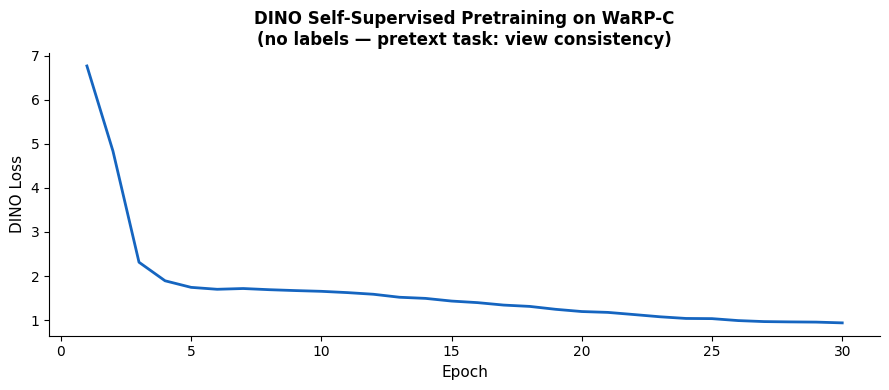

In [7]:
if 'history_dino' in dir():
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(range(1, len(history_dino)+1), history_dino,
            '#1565C0', lw=2)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('DINO Loss', fontsize=11)
    ax.set_title('DINO Self-Supervised Pretraining on WaRP-C\n'
                 '(no labels — pretext task: view consistency)',
                 fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    save = root / 'Dataset/figures/dino_pretrain_loss.png'
    save.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()


## Transfer: DINO Backbone to Classifier

Now we take the DINO-pretrained Swin backbone and attach
your classification head. The DINO head is discarded.

This is exactly the transfer learning paradigm from slide 10:
*'Pre-trained DNN on Large Scale Unlabeled datasets →
Transfer Learning on Downstream Tasks'*

**Class-weighted loss** gives 5× penalty for the 5 hard classes.
This directly targets the confusion matrix failures.

In [8]:
pp = WaRPPreprocessor(
    raw_root       = root / 'Dataset/raw/WaRP-C',
    processed_root = root / 'Dataset/processed',
    stats_file     = root / 'Dataset/dataset_stats.json',
    batch_size     = 32, num_workers  = 0,
    mean = [0.485,0.456,0.406], std = [0.229,0.224,0.225],
)
train_loader, test_loader = pp.get_loaders(model_type='mobilevit')
CLASS_NAMES = sorted(
    d.name for d in (root/'Dataset/processed/train').iterdir()
    if d.is_dir()
)
print(f'Classes: {len(CLASS_NAMES)}')


[get_loaders] model='mobilevit'
  sampler=True  minority_aug=True  mixup=False  pipeline='pretrained_cnn_gentle'
  train=273 batches  test=49 batches  sampler=WeightedRandom
Classes: 28


In [9]:
# Build class weights — 5x on hard classes
class_weights = torch.ones(NUM_CLASSES, device=DEVICE)
for cls in HARD_CLASSES:
    if cls in CLASS_NAMES:
        idx = CLASS_NAMES.index(cls)
        class_weights[idx] = 5.0
        print(f'  Hard class weight 5x: {cls} (idx={idx})')

criterion = nn.CrossEntropyLoss(
    weight      = class_weights,
    label_smoothing = 0.1
)


  Hard class weight 5x: bottle-oil-full (idx=13)
  Hard class weight 5x: bottle-multicolor (idx=10)
  Hard class weight 5x: bottle-multicolorv-full (idx=11)
  Hard class weight 5x: bottle-blue5l-full (idx=3)
  Hard class weight 5x: detergent-transparent (idx=21)


In [10]:
# Build DINO-initialised classifier
dino_cls = SwinTransformerWaRP(
    num_classes=NUM_CLASSES, pretrained=False
).to(DEVICE)

# Load DINO-pretrained backbone weights
# student.backbone contains the pretrained Swin features
dino_cls.backbone.load_state_dict(student.backbone.state_dict())
print('DINO backbone transferred to classifier')

# EMA for fine-tuning
ema_cls = copy.deepcopy(dino_cls).eval()
for p in ema_cls.parameters():
    p.requires_grad_(False)


DINO backbone transferred to classifier


## Fine-Tuning on WaRP-C (with class-weighted loss)

In [11]:
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            preds    = model(imgs.to(DEVICE)).argmax(1).cpu()
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
    return correct / total * 100


HEAD_LR     = 1e-4
BACKBONE_LR = 5e-5
WARMUP_EP   = 15
TOTAL_EP    = 60

dino_cls.freeze_backbone()
optimizer = torch.optim.AdamW(
    dino_cls.head.parameters(),
    lr=HEAD_LR, weight_decay=0.05
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=WARMUP_EP
)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda'))

train_accs, test_accs, train_losses = [], [], []
best_acc  = 0.0
SAVE_PATH = root / 'Models/weights/swin_dino_finetuned.pth'

print('Phase 1 — frozen backbone, training head')
for epoch in range(1, WARMUP_EP + 1):
    dino_cls.train()
    ep_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):
            loss = criterion(dino_cls(imgs), lbls)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(dino_cls.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        # EMA update
        with torch.no_grad():
            for ep, mp in zip(ema_cls.parameters(), dino_cls.parameters()):
                ep.data = ep.data * 0.999 + mp.data * 0.001
        ep_loss += loss.item()
    scheduler.step()
    tr_acc  = evaluate(dino_cls, train_loader)
    te_acc  = evaluate(ema_cls,  test_loader)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    train_losses.append(ep_loss / len(train_loader))
    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(ema_cls.state_dict(), SAVE_PATH)
    print(f'  Epoch {epoch:2d}/{WARMUP_EP}  '
          f'loss={train_losses[-1]:.4f}  '
          f'train={tr_acc:.2f}%  test={te_acc:.2f}%')

print('\nPhase 2 — full fine-tuning')
dino_cls.unfreeze_backbone()
optimizer = torch.optim.AdamW([
    {'params': dino_cls.backbone.parameters(), 'lr': BACKBONE_LR},
    {'params': dino_cls.head.parameters(),     'lr': HEAD_LR},
], weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=TOTAL_EP - WARMUP_EP
)

for epoch in range(WARMUP_EP + 1, TOTAL_EP + 1):
    dino_cls.train()
    ep_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):
            loss = criterion(dino_cls(imgs), lbls)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(dino_cls.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        with torch.no_grad():
            for ep, mp in zip(ema_cls.parameters(), dino_cls.parameters()):
                ep.data = ep.data * 0.999 + mp.data * 0.001
        ep_loss += loss.item()
    scheduler.step()
    tr_acc = evaluate(dino_cls, train_loader)
    te_acc = evaluate(ema_cls,  test_loader)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    train_losses.append(ep_loss / len(train_loader))
    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(ema_cls.state_dict(), SAVE_PATH)
    print(f'  Epoch {epoch:2d}/{TOTAL_EP}  '
          f'loss={train_losses[-1]:.4f}  '
          f'train={tr_acc:.2f}%  test={te_acc:.2f}%')

print(f'\nBest test accuracy: {best_acc:.2f}%')
print(f'Baseline Swin optimised: 81.56%')


[SwinTransformerWaRP] Backbone FROZEN — training head only
Phase 1 — frozen backbone, training head


C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_12172\434784881.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda'))
C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_12172\434784881.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):


  Epoch  1/15  loss=2.9819  train=23.56%  test=4.26%
  Epoch  2/15  loss=2.2523  train=33.04%  test=10.64%
  Epoch  3/15  loss=2.0958  train=35.62%  test=20.76%
  Epoch  4/15  loss=2.0411  train=38.59%  test=28.56%
  Epoch  5/15  loss=1.9899  train=39.86%  test=30.56%
  Epoch  6/15  loss=1.9486  train=40.22%  test=32.62%
  Epoch  7/15  loss=1.9822  train=40.89%  test=34.56%
  Epoch  8/15  loss=1.9343  train=42.06%  test=35.40%
  Epoch  9/15  loss=1.9477  train=41.29%  test=35.85%
  Epoch 10/15  loss=1.8903  train=41.44%  test=35.98%
  Epoch 11/15  loss=1.9387  train=42.45%  test=35.91%
  Epoch 12/15  loss=1.9148  train=41.31%  test=36.04%
  Epoch 13/15  loss=1.9206  train=42.31%  test=35.91%
  Epoch 14/15  loss=1.9344  train=41.71%  test=35.91%
  Epoch 15/15  loss=1.9225  train=42.24%  test=36.04%

Phase 2 — full fine-tuning
[SwinTransformerWaRP] Backbone UNFROZEN — full fine-tuning


C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_12172\434784881.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):


  Epoch 16/60  loss=1.7973  train=52.42%  test=37.14%
  Epoch 17/60  loss=1.6473  train=56.89%  test=40.94%
  Epoch 18/60  loss=1.5524  train=63.37%  test=44.36%
  Epoch 19/60  loss=1.4618  train=64.78%  test=47.00%
  Epoch 20/60  loss=1.4125  train=66.91%  test=50.29%
  Epoch 21/60  loss=1.3556  train=68.32%  test=52.48%
  Epoch 22/60  loss=1.2805  train=70.43%  test=55.19%
  Epoch 23/60  loss=1.2716  train=71.27%  test=56.67%
  Epoch 24/60  loss=1.2078  train=73.58%  test=58.61%
  Epoch 25/60  loss=1.2027  train=75.07%  test=59.32%
  Epoch 26/60  loss=1.1790  train=74.98%  test=59.90%
  Epoch 27/60  loss=1.1606  train=76.88%  test=60.48%
  Epoch 28/60  loss=1.1272  train=76.66%  test=61.70%
  Epoch 29/60  loss=1.1211  train=78.09%  test=62.54%
  Epoch 30/60  loss=1.0986  train=77.39%  test=63.31%
  Epoch 31/60  loss=1.0854  train=78.27%  test=63.70%
  Epoch 32/60  loss=1.0731  train=80.36%  test=64.54%
  Epoch 33/60  loss=1.0440  train=79.67%  test=65.31%
  Epoch 34/60  loss=1.0194  

## Training Curves

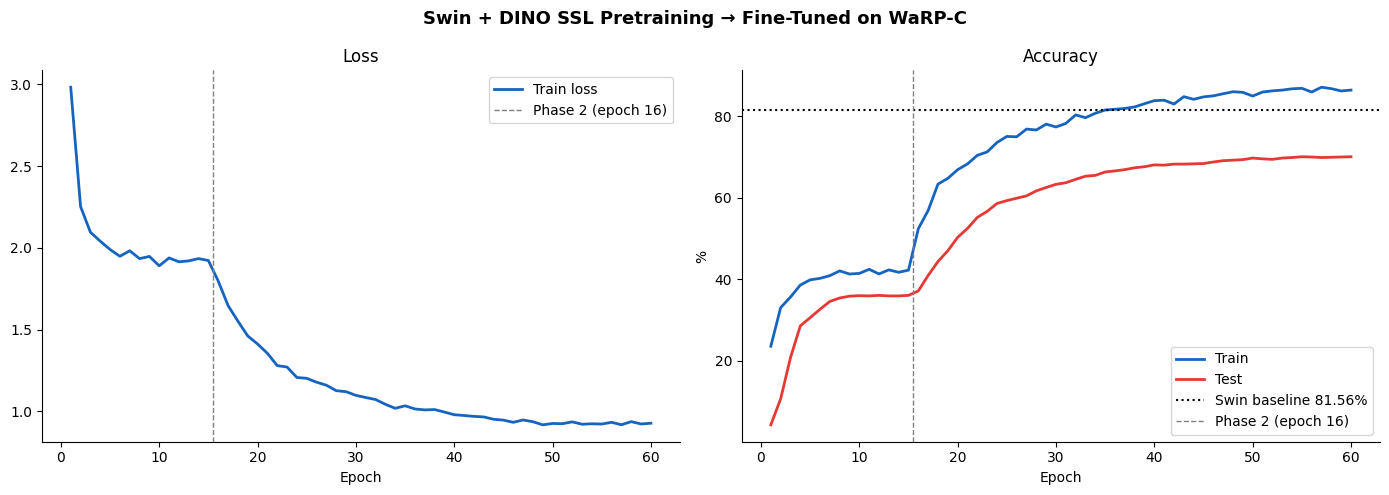

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(train_accs)+1)
phase_line   = dict(color='gray', linestyle='--', lw=1,
                    label=f'Phase 2 (epoch {WARMUP_EP+1})')

axes[0].plot(epochs_range, train_losses, '#1565C0', lw=2, label='Train loss')
axes[0].axvline(WARMUP_EP + 0.5, **phase_line)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_range, train_accs, '#1565C0', lw=2, label='Train')
axes[1].plot(epochs_range, test_accs,  '#E53935', lw=2, label='Test')
axes[1].axhline(81.56, color='black', linestyle=':',
                lw=1.5, label='Swin baseline 81.56%')
axes[1].axvline(WARMUP_EP + 0.5, **phase_line)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')
axes[1].legend()

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Swin + DINO SSL Pretraining -> Fine-Tuned on WaRP-C',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save = root / 'Dataset/figures/dino_finetune_curves.png'
save.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(save, dpi=150, bbox_inches='tight')
plt.show()


## Confusion Matrix on Hard Classes

In [13]:
ema_cls.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE,
                                    weights_only=True))
ema_cls.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        preds = ema_cls(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(lbls.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
final_acc  = (all_preds == all_labels).mean() * 100
print(f'DINO fine-tuned accuracy : {final_acc:.2f}%')
print(f'Swin baseline            : 81.56%')
print(f'Delta                    : {final_acc - 81.56:+.2f}%')

# Per-class accuracy on hard classes
print('\nHard class recovery:')
baselines = {
    'bottle-oil-full': 50, 'bottle-multicolor': 46,
    'bottle-multicolorv-full': 62, 'bottle-blue5l-full': 58,
    'detergent-transparent': 66,
}
for cls in HARD_CLASSES:
    if cls not in CLASS_NAMES: continue
    idx     = CLASS_NAMES.index(cls)
    mask    = all_labels == idx
    acc_cls = (all_preds[mask] == idx).mean() * 100 if mask.sum() > 0 else 0
    base    = baselines.get(cls, 0)
    print(f'  {cls:<30} {acc_cls:5.1f}%  (was {base}%  Δ={acc_cls-base:+.1f}%)')


DINO fine-tuned accuracy : 70.08%
Swin baseline            : 81.56%
Delta                    : -11.48%

Hard class recovery:
  bottle-oil-full                 37.5%  (was 50%  Δ=-12.5%)
  bottle-multicolor               57.1%  (was 46%  Δ=+11.1%)
  bottle-multicolorv-full         61.9%  (was 62%  Δ=-0.1%)
  bottle-blue5l-full              83.3%  (was 58%  Δ=+25.3%)
  detergent-transparent           68.3%  (was 66%  Δ=+2.3%)


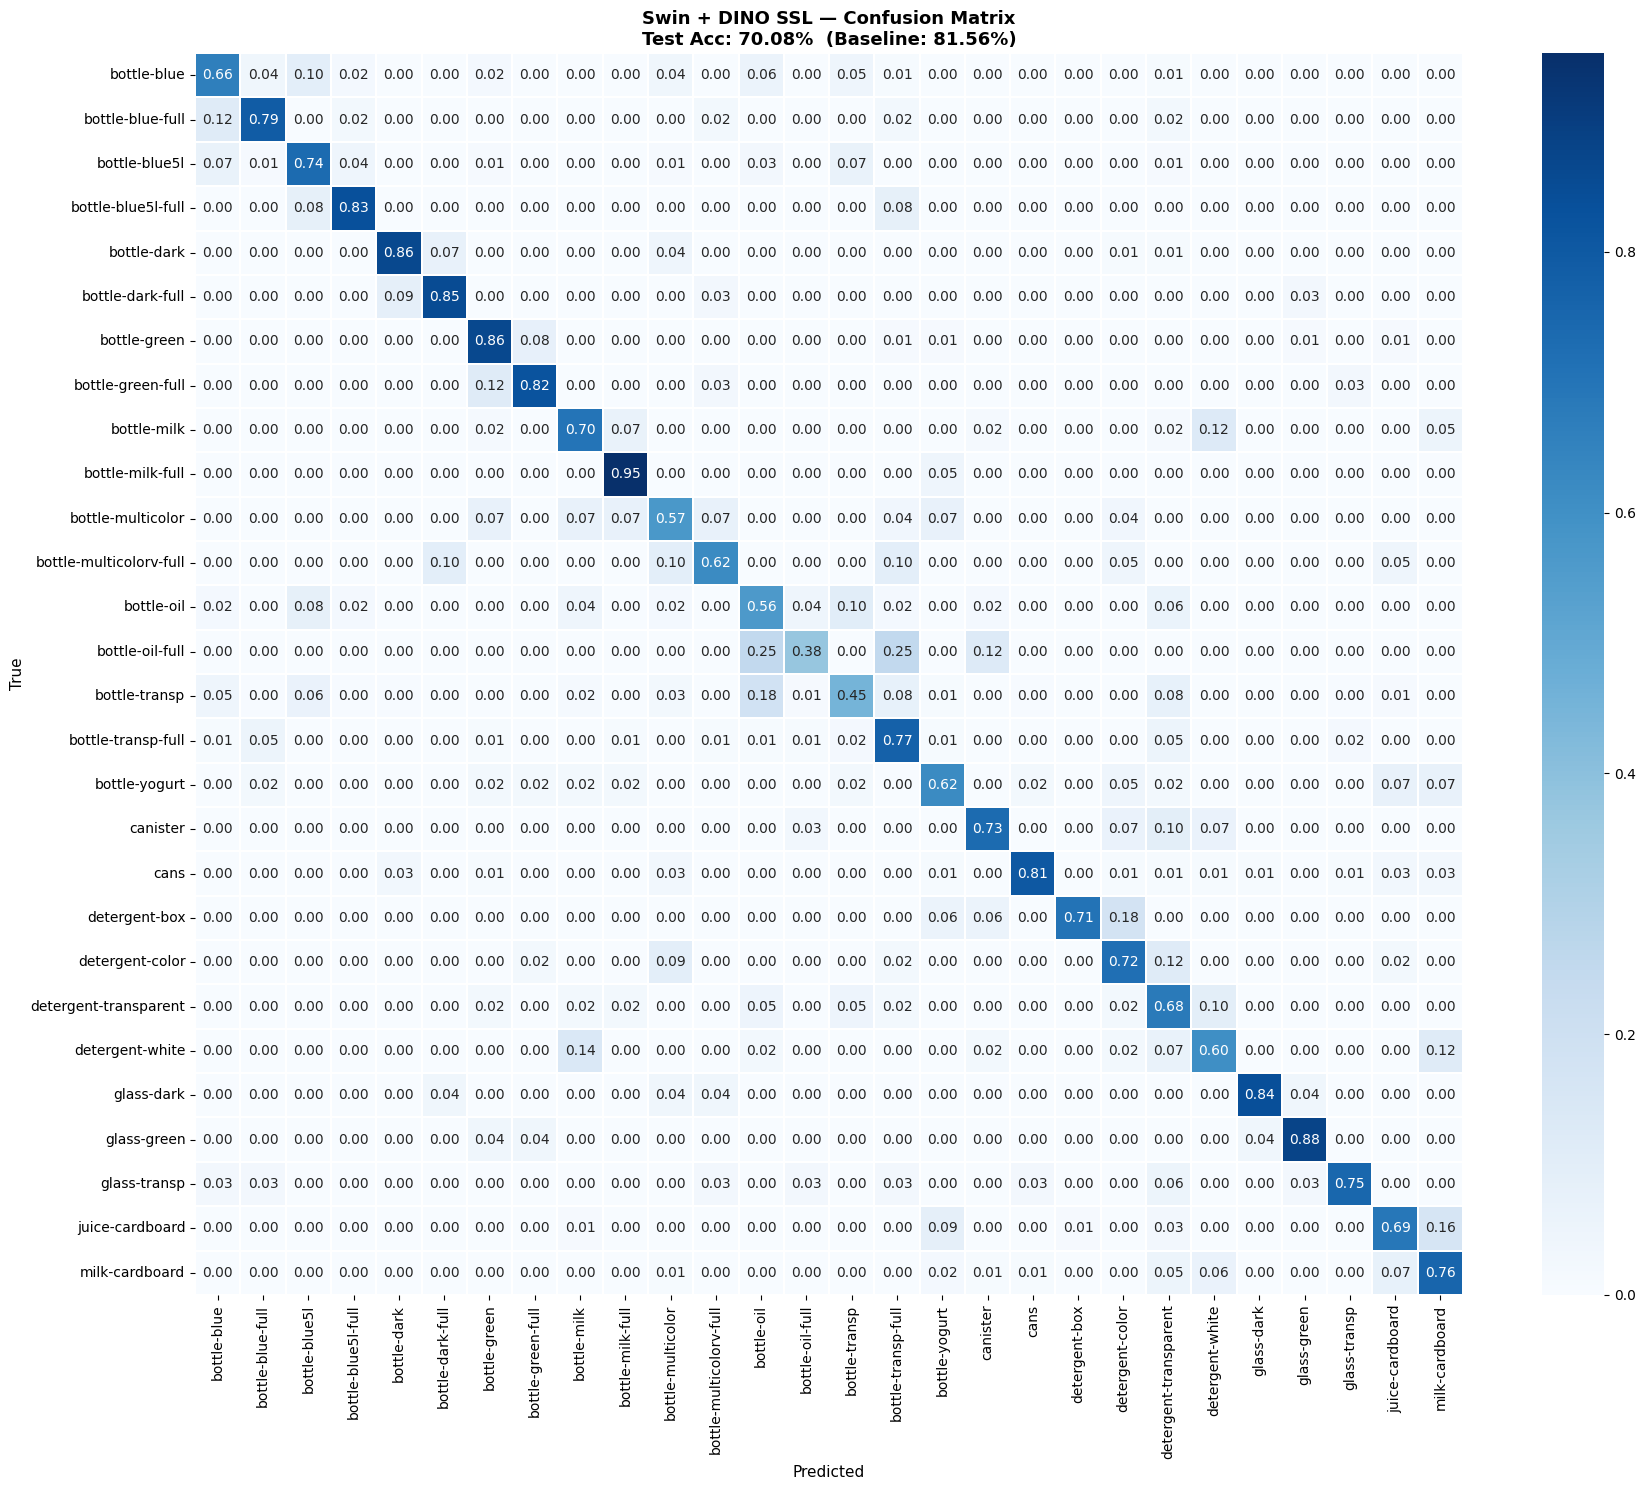

Saved → c:\Users\El Mehdi Ziate\Desktop\Waste-Classification\Dataset\figures\dino_confusion_matrix.png


In [ ]:
# Full confusion matrix
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.3, ax=ax)
ax.set_title(f'Swin + DINO SSL — Confusion Matrix\nTest Acc: {final_acc:.2f}%  '
             f'(Baseline: 81.56%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
plt.tight_layout()
save = root / 'Dataset/figures/dino_confusion_matrix.png'
plt.savefig(save, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {save}')



# Part 2 MIM: Masked Image Modelling with Swin

**Author:** El Mehdi Ziate




## MIM Augmentation and Masking

In [ ]:
class MIMTransform:
    """
    Transform for Masked Image Modelling on Swin.
    """
    def __init__(self, mask_ratio: float = 0.75,
                 grid_size: int = 7):
        self.mask_ratio = mask_ratio
        self.grid_size  = grid_size
        self.n_patches  = grid_size * grid_size   # 49
        self.n_mask     = int(self.n_patches * mask_ratio)

        self.transform = T.Compose([
            PadToSquare('reflect'),
            T.RandomResizedCrop(224, scale=(0.5, 1.0)),
            T.RandomHorizontalFlip(),
            T.ColorJitter(0.4, 0.4, 0.2, 0.05),
            T.ToTensor(),
            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])

    def __call__(self, img):
        x    = self.transform(img)       # (3, 224, 224)
        mask = self._random_mask()       # (49,) bool
        return x, mask

    def _random_mask(self) -> torch.Tensor:
        """Random block masking — slide 15b strategy."""
        mask = torch.zeros(self.n_patches, dtype=torch.bool)
        idx  = torch.randperm(self.n_patches)[:self.n_mask]
        mask[idx] = True
        return mask


class WaRPMIMDataset(Dataset):
    """WaRP-C dataset for MIM pretraining — ignores labels."""
    def __init__(self, root, transform):
        self.dataset   = ImageFolder(root, transform=None)
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        return self.transform(img)    # (image, mask)


mim_transform = MIMTransform(mask_ratio=0.75, grid_size=7)
mim_dataset   = WaRPMIMDataset(
    root      = root / 'Dataset/processed/train',
    transform = mim_transform,
)
mim_loader = DataLoader(
    mim_dataset, batch_size=32, shuffle=True,
    num_workers=0, pin_memory=(DEVICE=='cuda'),
)
print(f'MIM dataset: {len(mim_dataset)} images')
print(f'Patches: 7x7=49  Masked: {int(49*0.75)} (75%)')


MIM dataset: 8767 images
Patches: 7x7=49  Masked: 36 (75%)


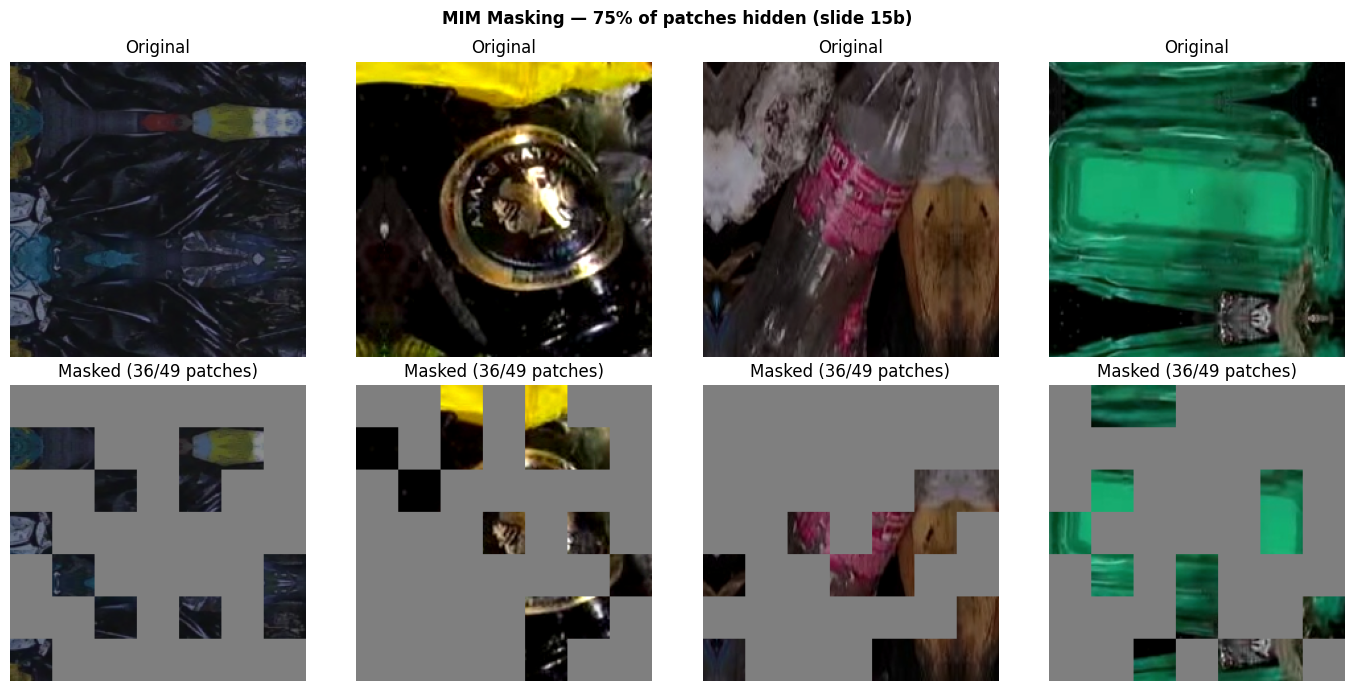

Saved → c:\Users\El Mehdi Ziate\Desktop\Waste-Classification\Dataset\figures\mim_masking_examples.png


In [ ]:
# Visualise the masking — show what the model sees
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('MIM Masking — 75% of patches hidden (slide 15b)',
             fontsize=12, fontweight='bold')

MEAN = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
STD  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

sample_imgs, sample_masks = next(iter(mim_loader))
for i in range(4):
    img  = sample_imgs[i].cpu()
    mask = sample_masks[i].cpu()       # (49,)

    # Denormalise
    img_vis = (img * STD + MEAN).clamp(0,1).permute(1,2,0).numpy()

    # Build mask overlay: reshape (49,) -> (7,7) -> (224,224)
    mask_2d  = mask.view(7,7).float()
    mask_224 = mask_2d.repeat_interleave(32, dim=0)\
                      .repeat_interleave(32, dim=1).numpy()
    masked   = img_vis.copy()
    masked[mask_224 > 0] = 0.5   # grey out masked patches

    axes[0, i].imshow(img_vis)
    axes[0, i].axis('off')
    axes[0, i].set_title('Original')

    axes[1, i].imshow(masked)
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Masked ({int(mask.sum())}/49 patches)')

plt.tight_layout()
save = root / 'Dataset/figures/mim_masking_examples.png'
save.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(save, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {save}')


## MIM Model (Swin Encoder + Lightweight Decoder)


In [ ]:
class SwinMIM(nn.Module):
    """
    Swin Transformer + MIM reconstruction decoder.
    """
    PATCH_SIZE   = 32    # Swin-Tiny: 224/7 = 32 pixels per patch
    GRID_SIZE    = 7
    N_PATCHES    = 49
    PATCH_PIXELS = 3 * 32 * 32   # 3072

    def __init__(self, pretrained_path: str = None):
        super().__init__()

        base = SwinTransformerWaRP(
            num_classes=NUM_CLASSES, pretrained=False
        )

        # Load YOUR saved best Swin weights as starting point
        if pretrained_path and Path(pretrained_path).exists():
            state = torch.load(pretrained_path, map_location='cpu',
                               weights_only=True)
            base.load_state_dict(state)
            print(f'[SwinMIM] Loaded pretrained weights from {pretrained_path}')
        else:
            print('[SwinMIM] Using random init (no pretrained path found)')

        self.backbone = base.backbone   # 768-dim output

        # MIM decoder: reconstruct patch pixels from 768-dim features
        # Input: 768-dim global feature (we broadcast to all patches)
        # Output: (N_patches, patch_pixels) = (49, 3072)
        self.decoder = nn.Sequential(
            nn.Linear(768, 1024),
            nn.GELU(),
            nn.Linear(1024, self.N_PATCHES * self.PATCH_PIXELS),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (B, 3, 224, 224)
        Returns: (B, 49, 3072) — predicted pixel values for all patches
        """
        feat = self.backbone(x)                        # (B, 768)
        pred = self.decoder(feat)                      # (B, 49*3072)
        return pred.view(-1, self.N_PATCHES, self.PATCH_PIXELS)

    def extract_patch_targets(self, x: torch.Tensor) -> torch.Tensor:
        """
        Extract ground-truth pixel values for each of the 49 patches.
        x : (B, 3, 224, 224)
        Returns: (B, 49, 3072)
        """
        B, C, H, W = x.shape
        P = self.PATCH_SIZE
        G = self.GRID_SIZE
        # Unfold into patches: (B, 49, 3*32*32)
        patches = x.unfold(2, P, P).unfold(3, P, P)  # (B,C,7,7,32,32)
        patches = patches.contiguous().view(B, C, G*G, P*P)
        patches = patches.permute(0, 2, 1, 3).contiguous()
        return patches.view(B, G*G, C*P*P)            # (B, 49, 3072)


# Load YOUR pretrained Swin as the starting point for MIM
mim_model = SwinMIM(
    pretrained_path = str(BEST_PATH)
).to(DEVICE)

total_p = sum(p.numel() for p in mim_model.parameters())
print(f'SwinMIM total params : {total_p:,}')


[SwinMIM] Loaded pretrained weights from c:\Users\El Mehdi Ziate\Desktop\Waste-Classification\Models\weights\swin_optimised_best.pth
SwinMIM total params : 182,598,010


## MIM Pretraining

Loss: **Mean Squared Error only on masked patches.**


In [ ]:
def train_mim(
    model, loader,
    epochs=30, lr=1e-4,
    save_path=None,
):
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=0.05
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )
    scaler  = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda'))
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0

        for images, masks in loader:
            images = images.to(DEVICE)   # (B, 3, 224, 224)
            masks  = masks.to(DEVICE)    # (B, 49) bool

            with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):
                # Ground truth patch pixels
                targets = model.extract_patch_targets(images)  # (B,49,3072)

                # Predicted patch pixels
                preds   = model(images)                         # (B,49,3072)

                # MSE loss only on masked patches (slide 14 inpainting)
                # masks: (B,49) -> expand to (B,49,3072)
                mask_exp = masks.unsqueeze(-1).expand_as(preds)
                loss = F.mse_loss(
                    preds[mask_exp], targets[mask_exp].detach()
                )

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()

        scheduler.step()
        avg = epoch_loss / len(loader)
        history.append(avg)
        print(f'Epoch {epoch:2d}/{epochs}  MIM loss={avg:.4f}')

        if save_path and epoch % 5 == 0:
            torch.save(model.state_dict(),
                       str(save_path).replace('.pth',f'_ep{epoch}.pth'))

    if save_path:
        torch.save(model.state_dict(), save_path)
        print(f'Saved -> {save_path}')
    return history


MIM_PRETRAIN_PATH = root / 'Models/weights/swin_mim_pretrained.pth'

if MIM_PRETRAIN_PATH.exists():
    print('MIM weights found — skipping pretraining')
    mim_model.load_state_dict(torch.load(
        MIM_PRETRAIN_PATH, map_location=DEVICE, weights_only=True
    ))
else:
    history_mim = train_mim(
        mim_model, mim_loader,
        epochs    = 30,
        lr        = 1e-4,
        save_path = MIM_PRETRAIN_PATH,
    )


C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_12172\3761101330.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda'))
C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_12172\3761101330.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):


Epoch  1/30  MIM loss=0.7363
Epoch  2/30  MIM loss=0.6457
Epoch  3/30  MIM loss=0.5961
Epoch  4/30  MIM loss=0.5232
Epoch  5/30  MIM loss=0.4503
Epoch  6/30  MIM loss=0.4136
Epoch  7/30  MIM loss=0.3800
Epoch  8/30  MIM loss=0.3683
Epoch  9/30  MIM loss=0.3519
Epoch 10/30  MIM loss=0.3338
Epoch 11/30  MIM loss=0.3195
Epoch 12/30  MIM loss=0.3164
Epoch 13/30  MIM loss=0.3069
Epoch 14/30  MIM loss=0.2994
Epoch 15/30  MIM loss=0.2971
Epoch 16/30  MIM loss=0.2909
Epoch 17/30  MIM loss=0.2835
Epoch 18/30  MIM loss=0.2830
Epoch 19/30  MIM loss=0.2786
Epoch 20/30  MIM loss=0.2762
Epoch 21/30  MIM loss=0.2737
Epoch 22/30  MIM loss=0.2716
Epoch 23/30  MIM loss=0.2690
Epoch 24/30  MIM loss=0.2725
Epoch 25/30  MIM loss=0.2682
Epoch 26/30  MIM loss=0.2682
Epoch 27/30  MIM loss=0.2667
Epoch 28/30  MIM loss=0.2631
Epoch 29/30  MIM loss=0.2673
Epoch 30/30  MIM loss=0.2634
Saved → c:\Users\El Mehdi Ziate\Desktop\Waste-Classification\Models\weights\swin_mim_pretrained.pth


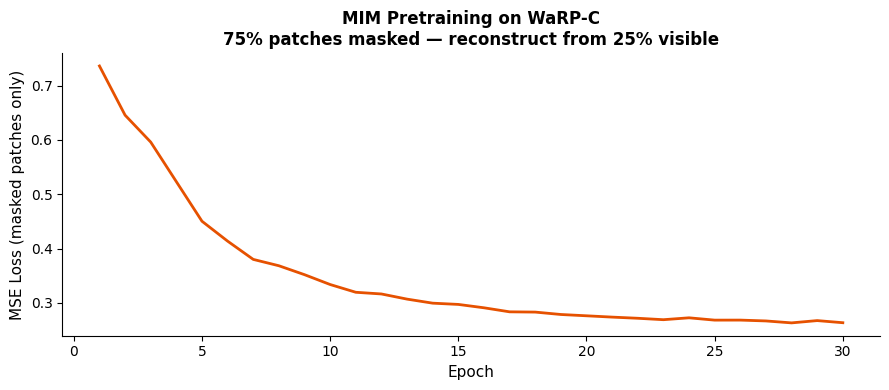

Saved → c:\Users\El Mehdi Ziate\Desktop\Waste-Classification\Dataset\figures\mim_pretrain_loss.png


In [ ]:
if 'history_mim' in dir():
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(range(1, len(history_mim)+1), history_mim, '#E65100', lw=2)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('MSE Loss (masked patches only)', fontsize=11)
    ax.set_title('MIM Pretraining on WaRP-C\n'
                 '75% patches masked — reconstruct from 25% visible',
                 fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    save = root / 'Dataset/figures/mim_pretrain_loss.png'
    plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {save}')


## Transfer MIM Backbone to Classifier


In [20]:
# Build MIM-initialised classifier
mim_cls = SwinTransformerWaRP(
    num_classes=NUM_CLASSES, pretrained=False
).to(DEVICE)

# Transfer the MIM-pretrained backbone
mim_cls.backbone.load_state_dict(mim_model.backbone.state_dict())
print('MIM backbone transferred to classifier')

# EMA
ema_mim = copy.deepcopy(mim_cls).eval()
for p in ema_mim.parameters():
    p.requires_grad_(False)


MIM backbone transferred to classifier


In [22]:
import gc
torch.cuda.empty_cache()
gc.collect()

# Load MIM pretrained backbone — skip Phase 1 entirely
mim_cls = SwinTransformerWaRP(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
mim_model_reload = SwinMIM(pretrained_path=None).to(DEVICE)
mim_model_reload.load_state_dict(torch.load(
    MIM_PRETRAIN_PATH, map_location=DEVICE, weights_only=True
))
mim_cls.backbone.load_state_dict(mim_model_reload.backbone.state_dict())
del mim_model_reload
torch.cuda.empty_cache()
print('MIM pretrained backbone loaded from saved checkpoint')

ema_mim = copy.deepcopy(mim_cls).eval()
for p in ema_mim.parameters():
    p.requires_grad_(False)

SAVE_PATH_MIM  = root / 'Models/weights/swin_mim_finetuned.pth'
CKPT_PATH_MIM  = root / 'Models/weights/swin_mim_checkpoint.pth'
TOTAL_EP       = 40
scaler_m       = torch.amp.GradScaler('cuda', enabled=(DEVICE=='cuda'))

train_accs_m, test_accs_m, train_losses_m = [], [], []
best_acc_m  = 0.0
start_epoch = 1

# Resume from checkpoint if kernel was interrupted
if CKPT_PATH_MIM.exists():
    ckpt = torch.load(CKPT_PATH_MIM, map_location=DEVICE, weights_only=False)
    mim_cls.load_state_dict(ckpt['model'])
    ema_mim.load_state_dict(ckpt['ema'])
    train_accs_m   = ckpt['train_accs']
    test_accs_m    = ckpt['test_accs']
    train_losses_m = ckpt['train_losses']
    best_acc_m     = ckpt['best_acc']
    start_epoch    = ckpt['epoch'] + 1
    print(f'Resumed from epoch {start_epoch-1}  best={best_acc_m:.2f}%')

# Full fine-tuning from epoch 1 — no frozen phase for MIM
# MIM features need joint backbone+head optimisation
mim_cls.unfreeze_backbone()
optimizer_m = torch.optim.AdamW([
    {'params': mim_cls.backbone.parameters(), 'lr': 2e-5},
    {'params': mim_cls.head.parameters(),     'lr': 1e-4},
], weight_decay=0.05)
scheduler_m = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_m, T_max=TOTAL_EP, last_epoch=start_epoch - 2
)

print('MIM fine-tuning — full from epoch 1 (no frozen phase)')
for epoch in range(start_epoch, TOTAL_EP + 1):
    mim_cls.train()
    ep_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=(DEVICE=='cuda')):
            loss = criterion(mim_cls(imgs), lbls)
        optimizer_m.zero_grad()
        scaler_m.scale(loss).backward()
        scaler_m.unscale_(optimizer_m)
        torch.nn.utils.clip_grad_norm_(mim_cls.parameters(), 1.0)
        scaler_m.step(optimizer_m)
        scaler_m.update()
        with torch.no_grad():
            for ep, mp in zip(ema_mim.parameters(), mim_cls.parameters()):
                ep.data = ep.data * 0.999 + mp.data * 0.001
        ep_loss += loss.item()

    scheduler_m.step()
    tr_acc = evaluate(mim_cls, train_loader)
    te_acc = evaluate(ema_mim, test_loader)
    train_accs_m.append(tr_acc)
    test_accs_m.append(te_acc)
    train_losses_m.append(ep_loss / len(train_loader))

    if te_acc > best_acc_m:
        best_acc_m = te_acc
        torch.save(ema_mim.state_dict(), SAVE_PATH_MIM)

    # Save checkpoint every epoch so kernel restart can resume
    torch.save({
        'epoch':        epoch,
        'model':        mim_cls.state_dict(),
        'ema':          ema_mim.state_dict(),
        'train_accs':   train_accs_m,
        'test_accs':    test_accs_m,
        'train_losses': train_losses_m,
        'best_acc':     best_acc_m,
    }, CKPT_PATH_MIM)

    print(f'  Epoch {epoch:2d}/{TOTAL_EP}  '
          f'loss={train_losses_m[-1]:.4f}  '
          f'train={tr_acc:.2f}%  test={te_acc:.2f}%'
          f'{"  ★" if te_acc == best_acc_m else ""}')

print(f'\nMIM best accuracy: {best_acc_m:.2f}%')
print(f'Baseline Swin   : 81.56%')

[SwinMIM] Using random init (no pretrained path found)
MIM pretrained backbone loaded from saved checkpoint
[SwinTransformerWaRP] Backbone UNFROZEN — full fine-tuning
MIM fine-tuning — full from epoch 1 (no frozen phase)
  Epoch  1/40  loss=2.9910  train=7.60%  test=2.84%  ★
  Epoch  2/40  loss=2.6468  train=15.77%  test=2.84%  ★
  Epoch  3/40  loss=2.3946  train=25.70%  test=4.26%  ★
  Epoch  4/40  loss=2.1768  train=37.65%  test=5.35%  ★
  Epoch  5/40  loss=1.9728  train=46.17%  test=7.61%  ★
  Epoch  6/40  loss=1.7382  train=54.97%  test=13.22%  ★
  Epoch  7/40  loss=1.5615  train=62.19%  test=21.21%  ★
  Epoch  8/40  loss=1.3641  train=73.18%  test=28.37%  ★
  Epoch  9/40  loss=1.2297  train=82.90%  test=35.33%  ★
  Epoch 10/40  loss=1.1215  train=86.64%  test=45.13%  ★
  Epoch 11/40  loss=1.0024  train=88.78%  test=56.03%  ★
  Epoch 12/40  loss=0.9386  train=90.43%  test=64.28%  ★
  Epoch 13/40  loss=0.9083  train=92.22%  test=69.95%  ★
  Epoch 14/40  loss=0.8780  train=92.66%  te

## Final Comparison: Baseline vs DINO vs MIM

In [23]:
# Load all best models and evaluate
results = {}

# Baseline Swin (your existing best model)
swin_base = SwinTransformerWaRP(
    num_classes=NUM_CLASSES, pretrained=False
).to(DEVICE)
if BEST_PATH.exists():
    swin_base.load_state_dict(torch.load(
        BEST_PATH, map_location=DEVICE, weights_only=True
    ))
    results['Swin (ImageNet baseline)'] = evaluate(swin_base, test_loader)
    print(f'Baseline: {results["Swin (ImageNet baseline)"]:.2f}%')

# DINO fine-tuned
if SAVE_PATH.exists():
    ema_cls.load_state_dict(torch.load(
        SAVE_PATH, map_location=DEVICE, weights_only=True
    ))
    results['Swin + DINO SSL'] = evaluate(ema_cls, test_loader)
    print(f'DINO: {results["Swin + DINO SSL"]:.2f}%')

# MIM fine-tuned
if SAVE_PATH_MIM.exists():
    ema_mim.load_state_dict(torch.load(
        SAVE_PATH_MIM, map_location=DEVICE, weights_only=True
    ))
    results['Swin + MIM SSL'] = evaluate(ema_mim, test_loader)
    print(f'MIM: {results["Swin + MIM SSL"]:.2f}%')


Baseline: 81.56%
DINO: 70.08%
MIM: 79.69%


In [25]:
# Hard class per-class breakdown for all three models
print('\nHard class recovery across all methods:')
print(f'{"Class":<30} {"Baseline":>10} {"DINO":>10} {"MIM":>10}')
print('-' * 65)

def get_class_acc(model, loader, class_idx):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
            mask  = lbls == class_idx
            if mask.sum() == 0: continue
            correct += (preds[mask] == class_idx).sum().item()
            total   += mask.sum().item()
    return correct / total * 100 if total > 0 else 0

for cls in HARD_CLASSES:
    if cls not in CLASS_NAMES: continue
    idx  = CLASS_NAMES.index(cls)
    base = get_class_acc(swin_base, test_loader, idx) \
           if BEST_PATH.exists() else 0
    dino = get_class_acc(ema_cls, test_loader, idx) \
           if SAVE_PATH.exists() else 0
    mim  = get_class_acc(ema_mim, test_loader, idx) \
           if SAVE_PATH_MIM.exists() else 0
    print(f'  {cls:<28} {base:>9.1f}%  {dino:>8.1f}%  {mim:>8.1f}%')



Hard class recovery across all methods:
Class                            Baseline       DINO        MIM
-----------------------------------------------------------------
  bottle-oil-full                   37.5%      37.5%      62.5%
  bottle-multicolor                 46.4%      57.1%      53.6%
  bottle-multicolorv-full           61.9%      61.9%      66.7%
  bottle-blue5l-full                58.3%      83.3%      58.3%
  detergent-transparent             65.9%      68.3%      70.7%
